In [10]:
from figure import * 
from quantum_circuit import * 
from post_processing_tool import *
from qiskit_aer import AerSimulator
from qiskit import transpile
import numpy as np 
import random
def get_1d_qc(spin,angle,build=True ):  
    # get all possible circuit
    qc_info=[]
    for i in range(spin):
        qc_info.append(pbc_qc(spin,angle,i, build ))
    return qc_info
def Mangetization(final_counts, shots): 
    mag = 0
    for i in final_counts.keys(): 
        mag+= (final_counts[i]/shots)*(cal_mag(i))
    return mag

In [11]:
temps = np.arange(0.1,3,0.1)
start = 1e-2  # Start value (minimum value)
stop = 1e2    # Stop value (maximum value)
num_points = 10 # Number of points to sample
# Generate evenly spaced samples in log scale
hs = np.logspace(np.log10(start), np.log10(stop), num=num_points)
all_circuit = []
temp_circuit=[]
temp = 1
z_prob = np.exp(-4/temp)
z_angle = 2*np.arccos(np.sqrt(z_prob))
spin = 4
aux_qc_info = get_1d_qc(spin,z_angle,build=True)
mcqc_info = get_1d_qc(spin,z_angle,build=False)
shots = 8192
print("start temp: ", temp)
h_circuit = []
for h in hs: 
    initial_aux = QuantumCircuit(spin+2, 1)
    initial_aux.x(0), initial_aux.x(2) 
    initial_mcqc = QuantumCircuit(spin+2, spin)
    initial_mcqc.x(0), initial_mcqc.x(2)
    initial_aux.cx(0,1)
    for _ in range(20):
        pick = random.randint(0, spin-1) 
        initial_aux.compose(aux_qc_info[pick], inplace=True)
        initial_aux.measure(pick,-1)
        aer_sim = AerSimulator()
        qc = transpile(initial_aux, aer_sim)
        final_counts = aer_sim.run([qc], shots=shots).result().get_counts()
        prob = np.zeros(shape=(1,2))
        for i in final_counts.keys():
            prob[0,int(i)] = final_counts[i]
        x_prob = prob[0,0]/shots 
        x_angle = 2*np.arccos(np.sqrt(x_prob))
        energy = cal_field_energy(x_angle)
        initial_aux.remove_final_measurements()
        initial_mcqc.compose(mcqc_info[pick],inplace=True)
        if energy > 0:
            # we do energy here
            x_prob = np.exp(-energy*h/temp)
            x_angle = 2*np.arccos(np.sqrt(x_prob))
            initial_mcqc.ry(x_angle,pick)
            initial_aux.ry(x_angle,pick)
    h_circuit.append(initial_mcqc)
temp_circuit.append(h_circuit)


start temp:  1


Text(0, 0.5, 'Magnetization')

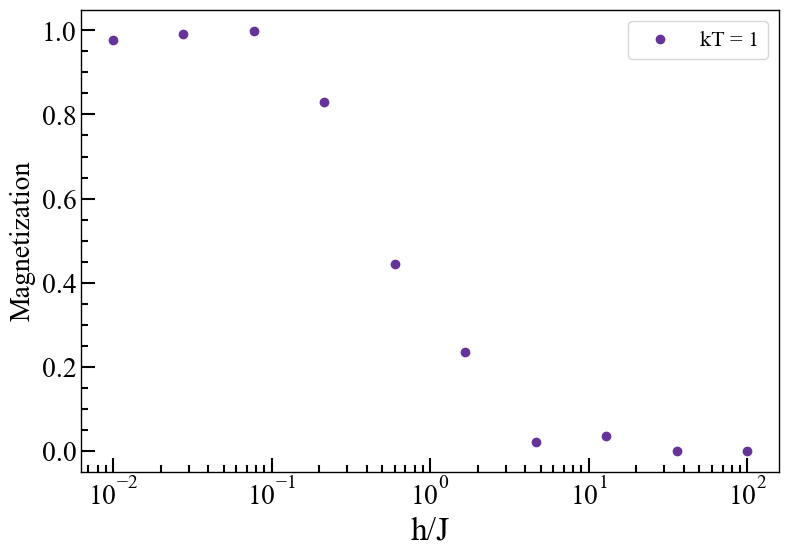

In [14]:
Mag= []
for circuit in h_circuit:
    for i in range(spin):
        circuit.measure(i,i)
    qc = transpile(circuit,aer_sim)
    final_counts = aer_sim.run(qc, shots=shots).result().get_counts()
    mag = Mangetization(final_counts,shots)
    Mag.append(mag)
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(hs, Mag, color='rebeccapurple', label='kT = 1')
ax.legend(prop = font3)
ax.minorticks_on()
ax.tick_params(axis='x', which='minor', direction='in', length=5, width= 1.5)
ax.tick_params(axis='y', which='minor', direction='in', length=5, width= 1.5)
ax.legend(prop = font3, ncol=2)
ax.spines["top"].set_linewidth(standard)
ax.spines["bottom"].set_linewidth(standard)
ax.spines["right"].set_linewidth(standard)
ax.spines["left"].set_linewidth(standard)
labels = ax.get_yticklabels() + ax.get_xticklabels() 
[label.set_fontname('Times new roman') for label in labels]
[label.set_weight('normal') for label in labels]
ax.minorticks_on()
ax.tick_params(axis='x', labelsize =20, direction='in', length=10, width=1.5, )
ax.tick_params(axis='y', labelsize =20, direction='in', length=10, width=1.5, )
ax.set_xscale('log')
ax.set_xlabel('h/J', font1)
ax.set_ylabel('Magnetization', font2)
